# Nino3.4 SST Skill (correlation & nRMSE) & DJF Time Series

In [153]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import dask
from dask.distributed import wait

from esp_lab import data_access_e3sm as data_access
from esp_lab import data_access_obs as obs_access
from esp_lab import stats

from esp_lab.utils import spatial_utils as spatial
from esp_lab.utils import calendar_utils as cal
from esp_lab.utils import mov_utils as mov

from esp_lab.utils.dask_utils import (
    DaskConfig,
    get_cluster_client,
    close_cluster,
)

from esp_lab.diagnostics import S2DDiagnostics, S2DConfig

# Default figure output directory for this HPC environment.
FIGURE_OUTDIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag")
FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)


def figure_filename(*parts, ext="png"):
    """Build consistent, readable lowercase snake_case figure filenames."""
    import re

    clean_parts = ["fig"]
    for part in parts:
        if part is None:
            continue
        text = str(part).strip()
        if not text:
            continue
        text = re.sub(r"[^A-Za-z0-9]+", "_", text).strip("_").lower()
        if text:
            clean_parts.append(text)

    suffix = ext.lstrip(".").lower()
    return "_".join(clean_parts) + f".{suffix}"


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [154]:
print("xarray:", xr.__version__)
print("dask:", dask.__version__)

xarray: 2026.4.0
dask: 2026.3.0


In [155]:
# -----------------------------
# Dask setup
# -----------------------------
machine_env = os.environ.get("CLUSTER_TYPE", "local")

dask_cfg = DaskConfig(
    cluster_type=machine_env,   # "local", "slurm", "casper_pbs", or "none"
    workers=30,
    cores=4,
    memory="16GB",
    walltime="02:00:00",
    queue=None,
    project=None,
)

cluster, client = get_cluster_client(dask_cfg)

print(client)

<Client: 'tcp://127.0.0.1:38983' processes=30 threads=30, memory=502.97 GiB>


### Read in monthly SST field using I/O functions; Convert to seasonal mean

In [156]:
%%time
# -----------------------------
# Diagnostics configuration
# -----------------------------
field = "TS"

case_nens = 10
case_nlead = 24

data_dir = "/global/cfs/cdirs/e3sm/S2S2D/post_process"
case_prefix = "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL"
outdir = '/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/E3SMLE'

force_rewrite = True

members = [f"EN{i:02d}" for i in range(case_nens)]

years = 1980
yeare = 2018
yexcl = None

# Drift / skill climatology years
climy0 = 1980
climy1 = 2010

init_months = [5, 11]
init_years = {
    5: [y for y in np.arange(years, yeare + 1) if y != yexcl],
    11: [y for y in np.arange(years, yeare + 1) if y != yexcl],
}

# Regional coordinates mapping for the 13 indices
REGIONS_COORDS = {
    "Nino12": [270.0, 280.0, -10.0, 0.0],
    "Nino3": [210.0, 270.0, -5.0, 5.0],
    "Nino3.4": [190.0, 240.0, -5.0, 5.0],
    "Nino4": [160.0, 210.0, -5.0, 5.0],
    "TNA": [305.0, 345.0, 5.0, 25.0],
    "TSA": [330.0, 10.0, -20.0, 0.0],
    "PACWRAMPOOL": [60.0, 170.0, -15.0, 15.0],
    "AtlNino": [340.0, 360.0, -3.0, 3.0],
    "AtlMDR": [280.0, 350.0, 10.0, 20.0],
    "IOD": [50.0, 110.0, -10.0, 10.0],
    "TNI": [160.0, 280.0, -10.0, 10.0],
    "ONI": [190.0, 240.0, -5.0, 5.0],
    "RONI": [190.0, 240.0, -20.0, 20.0],
}

region_name = "IOD" #"AtlNino" #"Nino4" #"Nino3" #"Nino12" #"Nino3.4"
region = REGIONS_COORDS.get(region_name, [])

# Y-axis range configurations for each region/index
REGIONS_PLOT_SETTINGS = {
    "Nino12":      {"acc_lim": [-0.2, 1.0], "rmse_lim": [0.2, 1.8], "ts_lim": [-4.0, 4.0], "ts_yticks": [-4, -2, 0, 2, 4]},
    "Nino3":       {"acc_lim": [-0.2, 1.0], "rmse_lim": [0.2, 1.5], "ts_lim": [-3.0, 3.0], "ts_yticks": [-3, -1.5, 0, 1.5, 3]},
    "Nino3.4":     {"acc_lim": [-0.2, 1.0], "rmse_lim": [0.2, 1.5], "ts_lim": [-3.0, 3.0], "ts_yticks": [-3, -1.5, 0, 1.5, 3]},
    "Nino4":       {"acc_lim": [-0.2, 1.0], "rmse_lim": [0.2, 1.5], "ts_lim": [-3.0, 3.0], "ts_yticks": [-3, -1.5, 0, 1.5, 3]},
    "TNA":         {"acc_lim": [-0.2, 1.0], "rmse_lim": [0.2, 1.5], "ts_lim": [-2.0, 2.0], "ts_yticks": [-2, -1, 0, 1, 2]},
    "TSA":         {"acc_lim": [-0.2, 1.0], "rmse_lim": [0.2, 1.5], "ts_lim": [-2.0, 2.0], "ts_yticks": [-2, -1, 0, 1, 2]},
    "PACWRAMPOOL": {"acc_lim": [-0.2, 1.0], "rmse_lim": [0.2, 1.5], "ts_lim": [-2.0, 2.0], "ts_yticks": [-2, -1, 0, 1, 2]},
    "AtlNino":     {"acc_lim": [-0.2, 1.0], "rmse_lim": [0.2, 1.5], "ts_lim": [-2.0, 2.0], "ts_yticks": [-2, -1, 0, 1, 2]},
    "AtlMDR":      {"acc_lim": [-0.2, 1.0], "rmse_lim": [0.2, 1.5], "ts_lim": [-2.0, 2.0], "ts_yticks": [-2, -1, 0, 1, 2]},
    "IOD":         {"acc_lim": [-0.3, 0.8], "rmse_lim": [0.5, 2.0], "ts_lim": [-1.5, 1.5], "ts_yticks": [-1.5, -0.75, 0, 0.75, 1.5]},
    "TNI":         {"acc_lim": [-0.2, 1.0], "rmse_lim": [0.2, 1.8], "ts_lim": [-3.0, 3.0], "ts_yticks": [-3, -1.5, 0, 1.5, 3]},
    "ONI":         {"acc_lim": [-0.2, 1.0], "rmse_lim": [0.2, 1.5], "ts_lim": [-3.0, 3.0], "ts_yticks": [-3, -1.5, 0, 1.5, 3]},
    "RONI":        {"acc_lim": [-0.2, 1.0], "rmse_lim": [0.2, 1.5], "ts_lim": [-3.0, 3.0], "ts_yticks": [-3, -1.5, 0, 1.5, 3]},
}

plot_settings = REGIONS_PLOT_SETTINGS.get(region_name, {
    "acc_lim": [-0.2, 1.0],
    "rmse_lim": [0.2, 1.5],
    "ts_lim": [-3.0, 3.0],
    "ts_yticks": [-3, -1.5, 0, 1.5, 3]
})

realm = "atm"
grid = "180x360_aave"
freq = "monthly"
ts_split = "2yr"
engine = "netcdf4"

# Keep open-time chunking light/safe
chunks = {}

# Use this later after data are combined, before heavy operations
mchunk = {
    "Y": 3,
    "L": 24,
    "M": 2,
    "lat": 90,
    "lon": 180,
}

require_all_members = True
verify_field_name = True
verify_coverage = True

persist_intermediate = True
load_regional_series = True
convert_ts_to_degC = True

cfg = S2DConfig(
    field=field,
    data_dir=data_dir,
    case_prefix=case_prefix,
    members=members,
    nlead=case_nlead,
    init_months=init_months,
    init_years=init_years,
    region=region,
    region_name=region_name,
    climy0=climy0,
    climy1=climy1,
    outdir=outdir,
    force_rewrite=force_rewrite,
    realm=realm,
    grid=grid,
    freq=freq,
    ts_split=ts_split,
    engine=engine,
    chunks=chunks,
    require_all_members=require_all_members,
    verify_field_name=verify_field_name,
    verify_coverage=verify_coverage,
    persist_intermediate=persist_intermediate,
    load_regional_series=load_regional_series,
    convert_ts_to_degC=convert_ts_to_degC,
)

print(cfg)

S2DConfig(field='TS', case_prefix='WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL', data_dir='/global/cfs/cdirs/e3sm/S2S2D/post_process', members=['EN00', 'EN01', 'EN02', 'EN03', 'EN04', 'EN05', 'EN06', 'EN07', 'EN08', 'EN09'], nlead=24, init_months=[5, 11], init_years={5: [np.int64(1980), np.int64(1981), np.int64(1982), np.int64(1983), np.int64(1984), np.int64(1985), np.int64(1986), np.int64(1987), np.int64(1988), np.int64(1989), np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)], 11: [np.int64(1980), np.int64(1981), np.int64(1982), np.int64(1983), np.int64(1984), np.int64(198

In [157]:
%%time
# -----------------------------
# Load preprocessed E3SM Niño 3.4 regional SST index
# -----------------------------
results = {}
for m in cfg.init_months:
    outfile_mon = os.path.join(outdir, f"E3SMLE{m:02d}_{field}_N{case_nens:02d}_M{case_nlead:02d}_{cfg.region_name}SST_mon.nc")
    outfile_seas = os.path.join(outdir, f"E3SMLE{m:02d}_{field}_N{case_nens:02d}_M{case_nlead:02d}_{cfg.region_name}SST_seas.nc")
    
    ds_mon = xr.open_dataset(outfile_mon)
    ds_seas = xr.open_dataset(outfile_seas)
    
    results[m] = {
        "mon": ds_mon["sst"].load(),
        "seas": ds_seas["sst"].load(),
        "time_mon": ds_mon["time"].load(),
        "time_seas": ds_seas["time"].load(),
    }

# Set a mock diag object for the downstream drift removal and skill functions
diag = S2DDiagnostics(
    cfg=cfg,
    data_access=data_access,
    obs_access=obs_access,
    stats=stats,
    spatial=spatial,
    cal=cal,
)


CPU times: user 40.3 ms, sys: 15 ms, total: 55.3 ms
Wall time: 39.6 ms


In [158]:
# -----------------------------
# Load fixed landmask
# -----------------------------
outdir = cfg.outdir
fixed_dir = os.path.join(outdir, "fixed")
landmask_file = os.path.join(fixed_dir, "sftlf.E3SM.nc")
landmask = xr.open_dataarray(landmask_file)


In [159]:
# Regional monthly/seasonal model indices are already preprocessed and saved.


In [160]:
# -----------------------------
# Verify saved model regional series (optional sanity check)
# -----------------------------
for m in cfg.init_months:
    for freq_tag in ["seas", "mon"]:
        outfile = os.path.join(
            outdir,
            f"E3SMLE{m:02d}_{field}_N{case_nens:02d}_M{case_nlead:02d}_{cfg.region_name}SST_{freq_tag}.nc"
        )

        if not os.path.exists(outfile):
            print(f"[WARNING] Missing file: {outfile}")
            continue

        with xr.open_dataset(outfile) as ds:
            print(f"\nmonth={m}, freq={freq_tag}")
            print(ds)

            # quick sanity checks
            if "sst" in ds:
                print(
                    "  sst min/max:",
                    float(ds["sst"].min()),
                    float(ds["sst"].max())
                )
                print("  units:", ds["sst"].attrs.get("units", "N/A"))
                


month=5, freq=seas
<xarray.Dataset> Size: 29kB
Dimensions:  (Y: 39, L: 8, M: 10)
Coordinates:
  * Y        (Y) <U10 2kB '1980050100' '1981050100' ... '2018050100'
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
  * M        (M) <U4 160B 'EN00' 'EN01' 'EN02' 'EN03' ... 'EN07' 'EN08' 'EN09'
Data variables:
    sst      (Y, L, M) float64 25kB ...
    time     (Y, L) object 2kB ...
  sst min/max: -1.8572768490248635 2.816697980729817
  units: degC

month=5, freq=mon
<xarray.Dataset> Size: 84kB
Dimensions:  (Y: 39, L: 24, M: 10)
Coordinates:
  * Y        (Y) <U10 2kB '1980050100' '1981050100' ... '2018050100'
  * L        (L) int64 192B 1 2 3 4 5 6 7 8 9 10 ... 16 17 18 19 20 21 22 23 24
  * M        (M) <U4 160B 'EN00' 'EN01' 'EN02' 'EN03' ... 'EN07' 'EN08' 'EN09'
Data variables:
    sst      (Y, L, M) float64 75kB ...
    time     (Y, L) object 7kB ...
  sst min/max: -2.4195138578398385 3.9073635407200555
  units: degC

month=11, freq=seas
<xarray.Dataset> Size: 29kB
Dimensions:  (Y: 39,

In [161]:
%%time
# -----------------------------
# Load preprocessed HadISST2 observations Niño 3.4 SST index and landmask
# -----------------------------
fixed_dir = os.path.join(outdir, "fixed")
obs_mask_file = os.path.join(fixed_dir, "sftlf.HadISST2.nc")
landmasko = xr.open_dataarray(obs_mask_file)

outfile_mon = os.path.join(outdir, f"HadISST2_sst_{cfg.region_name}SST_mon.nc")
outfile_seas = os.path.join(outdir, f"HadISST2_sst_{cfg.region_name}SST_seas.nc")

obs_mon = xr.open_dataset(outfile_mon)["sst"].load()
obs_seas = xr.open_dataset(outfile_seas)["sst"].load()

print("Obs Mon index:")
print(obs_mon)
print("\nObs Seas index:")
print(obs_seas)


Obs Mon index:
<xarray.DataArray 'sst' (time: 1848)> Size: 15kB
array([-0.9530356 , -0.63993577, -0.10247405, ..., -1.04170115,
       -0.59348025, -0.3626673 ], shape=(1848,))
Coordinates:
  * time     (time) object 15kB 1869-01-15 00:00:00 ... 2022-12-15 00:00:00
Attributes:
    long_name:  Indian Ocean Dipole regional mean SST
    region:     IOD
    units:      degC

Obs Seas index:
<xarray.DataArray 'sst' (time: 1846)> Size: 15kB
array([-0.56514845, -0.11542402,  0.09221442, ..., -1.53796201,
       -1.0039578 , -0.66595015], shape=(1846,))
Coordinates:
  * time     (time) object 15kB 1869-02-15 00:00:00 ... 2022-11-15 00:00:00
Attributes:
    long_name:  Indian Ocean Dipole regional mean SST
    region:     IOD
    units:      degC
CPU times: user 25.9 ms, sys: 9.02 ms, total: 34.9 ms
Wall time: 25.3 ms


In [162]:
%%time
# -----------------------------
# Drift removal using diagnostics class
# -----------------------------
results_dd = diag.remove_drift_for_results(results)

regsst_dd = {}
regsst_drift = {}
seas_regsst_dd = {}
seas_regsst_drift = {}

for m in cfg.init_months:
    regsst_dd[m] = results_dd[m]["mon_dd"]
    regsst_drift[m] = results_dd[m]["mon_drift"]

    seas_regsst_dd[m] = results_dd[m]["seas_dd"]
    seas_regsst_drift[m] = results_dd[m]["seas_drift"]

# convenient access
e3smle05_regsst_dd = regsst_dd.get(5)
e3smle11_regsst_dd = regsst_dd.get(11)

e3smle05_seas_regsst_dd = seas_regsst_dd.get(5)
e3smle11_seas_regsst_dd = seas_regsst_dd.get(11)

CPU times: user 7.42 ms, sys: 3.66 ms, total: 11.1 ms
Wall time: 10.3 ms


In [163]:
%%time
# -----------------------------
# Skill computation using diagnostics class
# -----------------------------
results_skill = diag.compute_skill_for_results(
    results_dd,
    obs_mon=obs_mon,
    obs_seas=obs_seas,
    seasonal_nlead=cfg.seasonal_nlead,
)

skill_mon = {}
skill_seas = {}

for m in cfg.init_months:
    skill_mon[m] = results_skill[m]["skill_mon"]
    skill_seas[m] = results_skill[m]["skill_seas"]

# convenient access
e3smle05_skill = skill_mon.get(5)
e3smle11_skill = skill_mon.get(11)

e3smle05_seas_skill = skill_seas.get(5)
e3smle11_seas_skill = skill_seas.get(11)

CPU times: user 1.59 s, sys: 457 ms, total: 2.05 s
Wall time: 1.8 s


In [164]:
# -----------------------------
# Combine skill arrays for plotting
# -----------------------------
startmonth = xr.DataArray(cfg.init_months, name="startmonth", dims="startmonth")

skill_list = [skill_mon[m] for m in cfg.init_months]
seas_skill_list = [skill_seas[m] for m in cfg.init_months]

e3smle_skill = xr.concat(skill_list, dim=startmonth)
e3smle_seas_skill = xr.concat(seas_skill_list, dim=startmonth)

print(e3smle_skill)
print(e3smle_seas_skill)

<xarray.Dataset> Size: 4kB
Dimensions:     (startmonth: 2, L: 24)
Coordinates:
  * startmonth  (startmonth) int64 16B 5 11
  * L           (L) int64 192B 1 2 3 4 5 6 7 8 9 ... 16 17 18 19 20 21 22 23 24
Data variables:
    corr        (startmonth, L) float64 384B 0.5138 0.4751 ... 0.2768 0.4648
    pval        (startmonth, L) float64 384B 0.000821 0.00224 ... 0.00287
    rmse        (startmonth, L) float64 384B 0.8608 0.9976 ... 1.077 0.8887
    msss        (startmonth, L) float64 384B 0.259 0.004795 ... -0.1602 0.2102
    rpc         (startmonth, L) float64 384B 0.5356 0.6182 ... 0.6017 0.9569
    sig_obs     (startmonth, L) float64 384B 0.4576 0.3671 ... 0.5867 0.7184
    sig_sig     (startmonth, L) float64 384B 0.2674 0.3469 ... 0.4479 0.3891
    sig_tot     (startmonth, L) float64 384B 0.2787 0.4515 ... 0.9737 0.8009
    s2t         (startmonth, L) float64 384B 0.9594 0.7685 ... 0.46 0.4858
<xarray.Dataset> Size: 1kB
Dimensions:     (startmonth: 2, L: 8)
Coordinates:
  * startmonth

### CESM-SMYLE benchmark comparison

This section follows the CESM-SMYLE benchmark workflow used in the skill-map notebooks, but applies it to the Niño3.4 regional SST index:

- load preprocessed CESM-SMYLE seasonal benchmark fields,
- compute the same Niño3.4 ocean regional mean,
- remove lead-dependent drift using the same climatology window,
- compute seasonal ACC/nRMSE skill against HadISST,
- make the benchmark available for the skill and DJF time-series plots.

**Significance interpretation:** filled ACC markers in the skill plot use each model's
correlation p-value against the null hypothesis of zero correlation. They do not test
whether E3SMLE is significantly better than CESM-SMYLE. A between-model superiority
claim would require the matched-ensemble resampling used in the map notebooks, applied
separately to ACC and nRMSE on the common verification years.


In [165]:
%%time
# -----------------------------
# Load preprocessed CESM-SMYLE Niño 3.4 regional SST index
# -----------------------------
from esp_lab import data_access_cesm_smyle as smyle_access

SMYLE_BENCHMARK_DIR = "/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE"
smyle_outdir = os.path.join(SMYLE_BENCHMARK_DIR, cfg.region_name)
smyle_nens = 20
smyle_nlead = case_nlead
smyle_force_rewrite = cfg.force_rewrite

smyle_seas_reg_by_month = {}
smyle_time_by_month = {}

for m in cfg.init_months:
    smyle_index_file = os.path.join(
        smyle_outdir,
        f"BSMYLE{m:02d}_{cfg.field}_N{smyle_nens:02d}_M{smyle_nlead:02d}_"
        f"{cfg.region_name}SST_seas.nc",
    )
    
    ds_idx = xr.open_dataset(smyle_index_file).load()
    smyle_seas_reg_by_month[m] = ds_idx["sst"]
    smyle_time_by_month[m] = ds_idx["time"]
    print(f"Loaded cached CESM-SMYLE regional index: {smyle_index_file}")

# Remove CESM-SMYLE drift using the same climatology window.
smyle_seas_dd_by_month = {}
smyle_seas_drift_by_month = {}

for m in cfg.init_months:
    smyle_seas_dd_by_month[m], smyle_seas_drift_by_month[m] = stats.remove_drift(
        smyle_seas_reg_by_month[m],
        smyle_time_by_month[m],
        climy0,
        climy1,
    )

# Compute or load CESM-SMYLE seasonal skill against HadISST.
smyle_skill_seas = {}
smyle_skill_detrend = True

for m in cfg.init_months:
    trend = "detrend" if smyle_skill_detrend else "nodetrend"
    smyle_skill_file = os.path.join(
        smyle_outdir,
        f"BSMYLE{m:02d}_{cfg.field}_{cfg.region_name}SST_skill_"
        f"clim_{climy0}_{climy1}_{trend}.nc",
    )

    if os.path.exists(smyle_skill_file) and not smyle_force_rewrite:
        skill_ds = xr.open_dataset(smyle_skill_file).load()
        print(f"Loaded cached CESM-SMYLE skill: {smyle_skill_file}")
    else:
        model_anom = smyle_seas_dd_by_month[m].chunk({"Y": -1, "L": -1, "M": -1})
        model_time = smyle_time_by_month[m]

        skill = stats.compute_skill_seasonal(
            model_anom,
            model_time,
            obs_seas,
            str(climy0),
            str(climy1),
            1,
            cfg.seasonal_nlead,
            resamp=0,
            detrend=smyle_skill_detrend,
        ).load()

        if isinstance(skill, xr.Dataset):
            skill_ds = skill
        else:
            skill_ds = xr.Dataset({
                "corr": skill.corr,
                "pval": skill.pval,
                "rmse": skill.rmse,
                "msss": skill.msss,
                "rpc": skill.rpc,
                "sig_obs": skill.sig_obs,
                "sig_sig": skill.sig_sig,
                "sig_tot": skill.sig_tot,
                "s2t": skill.s2t,
            })
        
        tmp_path = smyle_skill_file + ".tmp"
        if os.path.exists(tmp_path):
            os.remove(tmp_path)
        skill_ds.to_netcdf(tmp_path)
        os.replace(tmp_path, smyle_skill_file)
        print(f"Saved CESM-SMYLE skill: {smyle_skill_file}")

    smyle_skill_seas[m] = skill_ds

# Combine CESM-SMYLE data for plotting
smyle_startmonth = xr.DataArray(cfg.init_months, name="startmonth", dims="startmonth")
smyle_seas = xr.concat(
    [smyle_seas_dd_by_month[m] for m in cfg.init_months],
    dim=smyle_startmonth,
)
smyle_seas_time = xr.concat(
    [smyle_time_by_month[m] for m in cfg.init_months],
    dim=smyle_startmonth,
)
smyle_seas_skill_plot = xr.concat(
    [smyle_skill_seas[m] for m in cfg.init_months],
    dim=smyle_startmonth,
)


Loaded cached CESM-SMYLE regional index: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/IOD/BSMYLE05_TS_N20_M24_IODSST_seas.nc
Loaded cached CESM-SMYLE regional index: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/IOD/BSMYLE11_TS_N20_M24_IODSST_seas.nc


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


Saved CESM-SMYLE skill: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/IOD/BSMYLE05_TS_IODSST_skill_clim_1980_2010_detrend.nc


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


Saved CESM-SMYLE skill: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/IOD/BSMYLE11_TS_IODSST_skill_clim_1980_2010_detrend.nc
CPU times: user 9.29 s, sys: 9.44 s, total: 18.7 s
Wall time: 1min 4s


<timed exec>:96: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Y' ('Y',) The recommendation is to set join explicitly for this case.
<timed exec>:100: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Y' ('Y',) The recommendation is to set join explicitly for this case.


In [166]:
%%time
# -----------------------------
# Load preprocessed CESM-SMYLE monthly index and compute monthly skill
# -----------------------------
smyle_reg_by_month = {}
smyle_time_mon_by_month = {}
smyle_dd_by_month = {}
smyle_drift_by_month = {}
smyle_skill_mon = {}
smyle_skill_mon_detrend = True
smyle_force_rewrite = cfg.force_rewrite

for m in cfg.init_months:
    smyle_index_file = os.path.join(
        smyle_outdir,
        f"BSMYLE{m:02d}_{cfg.field}_N{smyle_nens:02d}_M{smyle_nlead:02d}_"
        f"{cfg.region_name}SST_mon.nc",
    )
    
    ds_idx = xr.open_dataset(smyle_index_file).load()
    smyle_reg_by_month[m] = ds_idx["sst"]
    smyle_time_mon_by_month[m] = ds_idx["time"]
    print(f"Loaded cached CESM-SMYLE monthly regional index: {smyle_index_file}")

    # Remove monthly lead-dependent drift
    smyle_dd_by_month[m], smyle_drift_by_month[m] = stats.remove_drift(
        smyle_reg_by_month[m],
        smyle_time_mon_by_month[m],
        climy0,
        climy1,
    )

    trend = "detrend" if smyle_skill_mon_detrend else "nodetrend"
    smyle_skill_file = os.path.join(
        smyle_outdir,
        f"BSMYLE{m:02d}_{cfg.field}_{cfg.region_name}SST_skill_mon_"
        f"clim_{climy0}_{climy1}_{trend}.nc",
    )

    if os.path.exists(smyle_skill_file) and not smyle_force_rewrite:
        skill_ds = xr.open_dataset(smyle_skill_file).load()
        print(f"Loaded cached CESM-SMYLE monthly skill: {smyle_skill_file}")
    else:
        model_anom = smyle_dd_by_month[m].chunk({"Y": -1, "L": -1, "M": -1})
        model_time = smyle_time_mon_by_month[m]

        # compute_skill_seasonal supports monthly means when monthly=True.
        skill = stats.compute_skill_seasonal(
            model_anom,
            model_time,
            obs_mon,
            climy0,
            climy1,
            nleadavg=1,
            nleads=cfg.nlead,
            resamp=0,
            detrend=smyle_skill_mon_detrend,
            monthly=True,
        ).load()

        if isinstance(skill, xr.Dataset):
            skill_ds = skill
        else:
            skill_ds = xr.Dataset({
                "corr": skill.corr,
                "pval": skill.pval,
                "rmse": skill.rmse,
                "msss": skill.msss,
                "rpc": skill.rpc,
                "sig_obs": skill.sig_obs,
                "sig_sig": skill.sig_sig,
                "sig_tot": skill.sig_tot,
                "s2t": skill.s2t,
            })
        
        tmp_path = smyle_skill_file + ".tmp"
        if os.path.exists(tmp_path):
            os.remove(tmp_path)
        skill_ds.to_netcdf(tmp_path)
        os.replace(tmp_path, smyle_skill_file)
        print(f"Saved CESM-SMYLE monthly skill: {smyle_skill_file}")

    smyle_skill_mon[m] = skill_ds

# Combine monthly CESM-SMYLE skill
smyle_startmonth = xr.DataArray(cfg.init_months, name="startmonth", dims="startmonth")
smyle = xr.concat(
    [smyle_dd_by_month[m] for m in cfg.init_months],
    dim=smyle_startmonth,
)
smyle_time = xr.concat(
    [smyle_time_mon_by_month[m] for m in cfg.init_months],
    dim=smyle_startmonth,
)
smyle_skill_plot = xr.concat(
    [smyle_skill_mon[m] for m in cfg.init_months],
    dim=smyle_startmonth,
)


Loaded cached CESM-SMYLE monthly regional index: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/IOD/BSMYLE05_TS_N20_M24_IODSST_mon.nc
Saved CESM-SMYLE monthly skill: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/IOD/BSMYLE05_TS_IODSST_skill_mon_clim_1980_2010_detrend.nc
Loaded cached CESM-SMYLE monthly regional index: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/IOD/BSMYLE11_TS_N20_M24_IODSST_mon.nc
Saved CESM-SMYLE monthly skill: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/IOD/BSMYLE11_TS_IODSST_skill_mon_clim_1980_2010_detrend.nc
CPU times: user 20.9 s, sys: 21.4 s, total: 42.3 s
Wall time: 2min 28s


<timed exec>:86: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Y' ('Y',) The recommendation is to set join explicitly for this case.
<timed exec>:90: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Y' ('Y',) The recommendation is to set join explicitly for this case.


Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_iod_iod_acc_skill.png


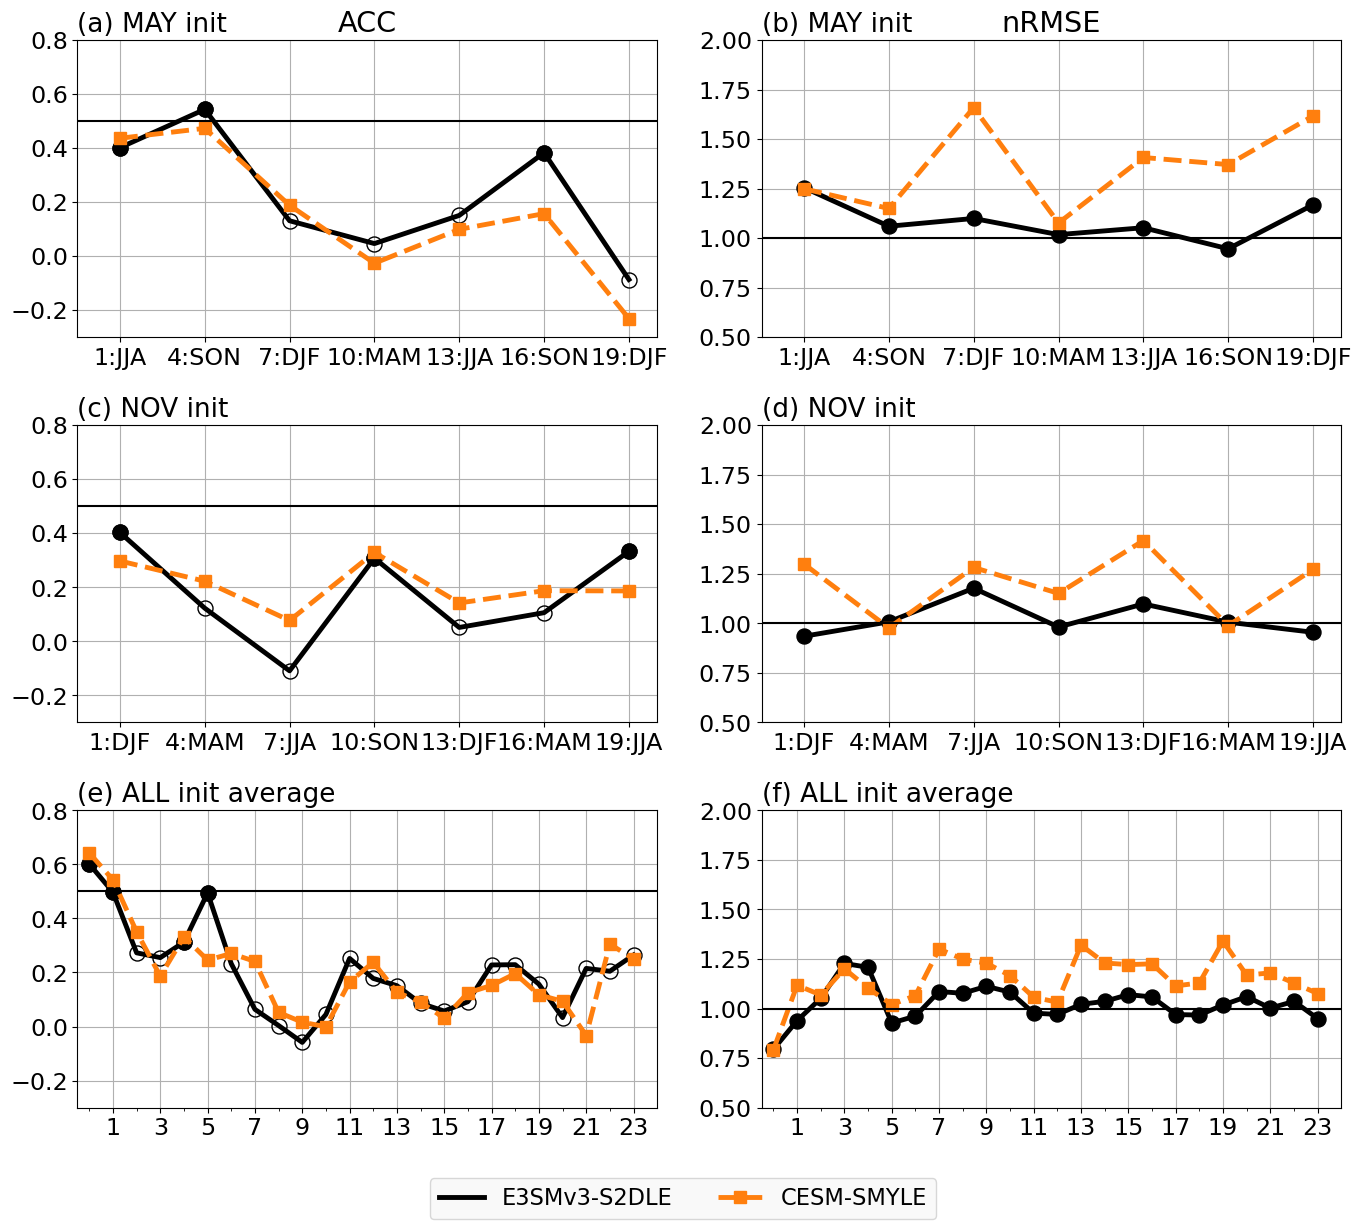

In [167]:
# -----------------------------
# Plot skill scores
# -----------------------------
# -----------------------------
# Plot setup: change values here to tune the figure
# -----------------------------
field = cfg.region_name
figfmt = "png"
period = f"{years}-{yeare}"
figname = figure_filename(field, f"{cfg.region_name.lower()}_acc_skill", ext=figfmt)
dpi = 300
save_bbox = "tight"

startmonths_requested = cfg.init_months
ncol = 2

fontz = 18
title_fontz = fontz * 1.05
header_fontz = fontz * 1.15
tick_fontz = fontz * 0.95
legend_fontz = fontz * 0.90

fig_width = 14
row_height = fig_width * 0.6 / ncol
line_width = 3.5
marker_size = fontz * 0.6
e3sm_marker_size = marker_size
smyle_marker_size = marker_size * 0.75

e3sm_label = "E3SMv3-S2DLE"
smyle_label = "CESM-SMYLE"
e3sm_color = "k"
smyle_color = "tab:orange"
smyle_linestyle = "--"
e3sm_marker = "o"
smyle_marker = "s"
significance_pval = 0.1
open_marker_fillstyle = "none"
marker_only_linestyle = "none"

hindcast_label = {2: "FEB init", 5: "MAY init", 8: "AUG init", 11: "NOV init"}
all_init_label = "ALL init average"
figlab_fmt = "({})"

season_labels_by_month = {
    2:  ["MAM", "JJA", "SON", "DJF", "MAM", "JJA", "SON", "DJF", "MAM", "JJA", "SON", "DJF"],
    5:  ["JJA", "SON", "DJF", "MAM", "JJA", "SON", "DJF", "MAM", "JJA", "SON", "DJF", "MAM"],
    8:  ["SON", "DJF", "MAM", "JJA", "SON", "DJF", "MAM", "JJA", "SON", "DJF", "MAM", "JJA"],
    11: ["DJF", "MAM", "JJA", "SON", "DJF", "MAM", "JJA", "SON", "DJF", "MAM", "JJA", "SON"],
}

seasonal_xlim = [-0.5, 20]
monthly_xlim = [-0.5, 24]
acc_ylim = plot_settings["acc_lim"]
seasonal_rmse_ylim = plot_settings["rmse_lim"]
monthly_rmse_ylim = plot_settings["rmse_lim"]
acc_hline = 0.5
rmse_hline = 1.0
hline_color = "black"
show_grid = True
acc_header = "ACC"
rmse_header = "nRMSE"
acc_yticks = np.arange(10) * 0.1 + 0.1
acc_yticklabels = ["0.1", "", "0.3", "", "0.5", "", "0.7", "", "0.9", ""]
rmse_yticks = np.arange(12) * 0.1 + 0.2
rmse_yticklabels = ["0.2", "", "0.4", "", "0.6", "", "0.8", "", "1.0", "", "1.2", ""]
monthly_xticks = np.arange(12) * 2 + 1
monthly_xticks_minor = np.arange(12) * 2
legend_locs = {"acc": "lower left", "rmse": "upper right"}

plt.rcParams.update({
    "font.size": fontz,
    "axes.titlesize": title_fontz,
    "xtick.labelsize": tick_fontz,
    "ytick.labelsize": tick_fontz,
    "legend.fontsize": legend_fontz,
})

# -----------------------------
# Derived plot values
# -----------------------------
leadsea = e3smle_seas_skill.L - 2
_nlead_seas = leadsea.sizes["L"]
xsea = {
    month: labels[:_nlead_seas]
    for month, labels in season_labels_by_month.items()
}
startmonths = [
    m for m in startmonths_requested
    if m in e3smle_seas_skill.startmonth.values
]
nrow = len(startmonths) + 1
fig = plt.figure(figsize=(fig_width, row_height * nrow))
figlabs = [figlab_fmt.format(chr(97 + i)) for i in range(nrow * ncol)]

# -----------------------------
# Seasonal skill panels by initialization month
# -----------------------------
for j, sm in enumerate(startmonths):
    sm_int = int(sm)
    ax = fig.add_subplot(nrow, ncol, j * 2 + 1)
    ax2 = fig.add_subplot(nrow, ncol, j * 2 + 2)

    label = hindcast_label.get(sm_int, f"{sm_int:02d} init")

    ax.set_title(figlabs[j * 2] + " " + label, loc="left", fontsize=title_fontz)
    ax2.set_title(figlabs[j * 2 + 1] + " " + label, loc="left", fontsize=title_fontz)

    if j == 0:
        ax.set_title(acc_header, loc="center", fontsize=header_fontz)
        ax2.set_title(rmse_header, loc="center", fontsize=header_fontz)

    tmp = e3smle_seas_skill.sel(startmonth=sm)

    ax.plot(tmp.L - 2, tmp.corr, color=e3sm_color, linewidth=line_width, label=e3sm_label)
    ax.plot(tmp.L - 2, tmp.corr, color=e3sm_color, marker=e3sm_marker, markersize=e3sm_marker_size, fillstyle=open_marker_fillstyle, linestyle=marker_only_linestyle)
    ax.plot(tmp.L - 2, tmp.corr.where(tmp.pval < significance_pval), color=e3sm_color, marker=e3sm_marker, markersize=e3sm_marker_size, linestyle=marker_only_linestyle)

    ax2.plot(tmp.L - 2, tmp.rmse, color=e3sm_color, linewidth=line_width, marker=e3sm_marker, markersize=e3sm_marker_size, label=e3sm_label)

    if "smyle_seas_skill_plot" in globals() and sm in smyle_seas_skill_plot.startmonth.values:
        tmp_smyle = smyle_seas_skill_plot.sel(startmonth=sm)
        ax.plot(
            tmp_smyle.L - 2,
            tmp_smyle.corr,
            color=smyle_color,
            linewidth=line_width,
            linestyle=smyle_linestyle,
            marker=smyle_marker,
            markersize=smyle_marker_size,
            label=smyle_label,
        )
        ax2.plot(
            tmp_smyle.L - 2,
            tmp_smyle.rmse,
            color=smyle_color,
            linewidth=line_width,
            linestyle=smyle_linestyle,
            marker=smyle_marker,
            markersize=smyle_marker_size,
            label=smyle_label,
        )

    xticklabs = [f"{int(leadsea[i].data)}:{xsea[sm_int][i]}" for i in range(_nlead_seas)]

    ax.set_xticks(leadsea)
    ax.set_xticklabels(xticklabs, fontsize=tick_fontz)
    # ax.set_yticks(acc_yticks)
    # ax.set_yticklabels(acc_yticklabels, fontsize=tick_fontz)
    ax.set_xlim(seasonal_xlim)
    ax.set_ylim(acc_ylim)
    ax.tick_params(axis="both", labelsize=tick_fontz)
    ax.grid(show_grid)
    ax.axhline(y=acc_hline, color=hline_color)

    ax2.set_xticks(leadsea)
    ax2.set_xticklabels(xticklabs, fontsize=tick_fontz)
    # ax2.set_yticks(rmse_yticks)
    # ax2.set_yticklabels(rmse_yticklabels, fontsize=tick_fontz)
    ax2.set_xlim(seasonal_xlim)
    ax2.set_ylim(seasonal_rmse_ylim)
    ax2.tick_params(axis="both", labelsize=tick_fontz)
    ax2.grid(show_grid)
    ax2.axhline(y=rmse_hline, color=hline_color)

    # if j == 0:
    #     ax.legend(loc=legend_locs["acc"], fontsize=legend_fontz)
    #     ax2.legend(loc=legend_locs["rmse"], fontsize=legend_fontz)

# -----------------------------
# Monthly ALL-init average panels
# -----------------------------
bottom_row = len(startmonths)
ax = fig.add_subplot(nrow, ncol, bottom_row * 2 + 1)
ax2 = fig.add_subplot(nrow, ncol, bottom_row * 2 + 2)

ax.set_title(figlabs[bottom_row * 2] + " " + all_init_label, loc="left", fontsize=title_fontz)
ax2.set_title(figlabs[bottom_row * 2 + 1] + " " + all_init_label, loc="left", fontsize=title_fontz)

tmp = e3smle_skill.mean("startmonth")

ax.plot(tmp.L - 1, tmp.corr, color=e3sm_color, linewidth=line_width, label=e3sm_label)
ax.plot(tmp.L - 1, tmp.corr, color=e3sm_color, marker=e3sm_marker, markersize=e3sm_marker_size, fillstyle=open_marker_fillstyle, linestyle=marker_only_linestyle)
ax.plot(tmp.L - 1, tmp.corr.where(tmp.pval < significance_pval), color=e3sm_color, marker=e3sm_marker, markersize=e3sm_marker_size, linestyle=marker_only_linestyle)

ax2.plot(tmp.L - 1, tmp.rmse, color=e3sm_color, linewidth=line_width, marker=e3sm_marker, markersize=e3sm_marker_size, label=e3sm_label)

if "smyle_skill_plot" in globals():
    # Bottom panels are monthly ALL-init averages, so use monthly CESM-SMYLE skill.
    tmp_smyle = smyle_skill_plot.mean("startmonth")
    ax.plot(
        tmp_smyle.L - 1,
        tmp_smyle.corr,
        color=smyle_color,
        linewidth=line_width,
        linestyle=smyle_linestyle,
        marker=smyle_marker,
        markersize=smyle_marker_size,
        label=smyle_label,
    )
    ax2.plot(
        tmp_smyle.L - 1,
        tmp_smyle.rmse,
        color=smyle_color,
        linewidth=line_width,
        linestyle=smyle_linestyle,
        marker=smyle_marker,
        markersize=smyle_marker_size,
        label=smyle_label,
    )
        # ax.legend(loc=legend_locs["acc"], fontsize=legend_fontz)
        # ax2.legend(loc=legend_locs["rmse"], fontsize=legend_fontz)

ax.set_xticks(monthly_xticks)
ax.set_xticks(monthly_xticks_minor, minor=True)
ax.tick_params(axis="both", labelsize=tick_fontz)
    # ax.set_yticks(acc_yticks)
    # ax.set_yticklabels(acc_yticklabels, fontsize=tick_fontz)
ax.set_xlim(monthly_xlim)
ax.set_ylim(acc_ylim)
ax.grid(show_grid)
ax.axhline(y=acc_hline, color=hline_color)

ax2.set_xticks(monthly_xticks)
ax2.set_xticks(monthly_xticks_minor, minor=True)
ax2.tick_params(axis="both", labelsize=tick_fontz)
    # ax2.set_yticks(rmse_yticks)
    # ax2.set_yticklabels(rmse_yticklabels, fontsize=tick_fontz)
ax2.set_xlim(monthly_xlim)
ax2.set_ylim(monthly_rmse_ylim)
ax2.grid(show_grid)
ax2.axhline(y=rmse_hline, color=hline_color)

# Collect handles and labels for a single 1-line legend at the bottom
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, 0.01),
    frameon=True,
    facecolor="#f9f9f9",
    edgecolor="lightgray",
    framealpha=0.9
)

fig.tight_layout(rect=[0, 0.06, 1, 1])
figpath = FIGURE_OUTDIR / figname
mov.save_figure(
    fig, figpath,
    mode="",
    metric=f"{cfg.region_name.lower()}_sst_skill",
    title=f"{cfg.region_name} SST Skill: {field}",
    caption=f"Verification period: {period}",
    dpi=dpi,
)
print("Saved figure:", figpath)
plt.show()


In [168]:
# -----------------------------
# DJF observed anomaly series
# -----------------------------
print(obs_seas.time)

jan = obs_seas.time.dt.month == 1
obs_djf = obs_seas.where(jan).dropna("time")
obs_djf = obs_djf - obs_djf.sel(time=slice(str(climy0), str(climy1))).mean("time")

<xarray.DataArray 'time' (time: 1846)> Size: 15kB
array([cftime.DatetimeNoLeap(1869, 2, 15, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1869, 3, 15, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1869, 4, 15, 0, 0, 0, 0, has_year_zero=True), ...,
       cftime.DatetimeNoLeap(2022, 9, 15, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2022, 10, 15, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2022, 11, 15, 0, 0, 0, 0, has_year_zero=True)],
      shape=(1846,), dtype=object)
Coordinates:
  * time     (time) object 15kB 1869-02-15 00:00:00 ... 2022-11-15 00:00:00


In [169]:
# -----------------------------
# Combine seasonal drift-corrected series
# (order follows cfg.init_months)
# -----------------------------
startmonth = xr.DataArray(cfg.init_months, name="startmonth", dims="startmonth")

e3smle_seas = xr.concat(
    [results_dd[m]["seas_dd"] for m in cfg.init_months],
    dim=startmonth
)

e3smle_seas_time = xr.concat(
    [results[m]["time_seas"] for m in cfg.init_months],
    dim=startmonth
)

e3smle_seas_skill_plot = xr.concat(
    [results_skill[m]["skill_seas"] for m in cfg.init_months],
    dim=startmonth
)

print(e3smle_seas)
print(e3smle_seas_time)
print(e3smle_seas_skill_plot)


<xarray.DataArray 'sst' (startmonth: 2, Y: 78, L: 8, M: 10)> Size: 100kB
array([[[[-0.15527419, -0.37591406, -0.39623019, ..., -0.03191662,
           0.86127717, -0.37117113],
         [ 0.3900574 ,  0.05043104, -0.22134988, ...,  0.20693915,
           1.60127485,  0.3108587 ],
         [-0.01230942, -0.45533095,  0.19339123, ..., -0.01003274,
           0.55615621, -0.01162445],
         ...,
         [ 0.50440981, -0.68527643, -0.40872001, ...,  0.17388392,
           0.05836916,  0.32116224],
         [ 0.03107455, -0.14003143,  0.07457145, ...,  0.01691683,
           0.37910583, -0.01473888],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan]],

        [[        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
            

/tmp/ipykernel_1394097/75750370.py:7: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Y' ('Y',) The recommendation is to set join explicitly for this case.
  e3smle_seas = xr.concat(
/tmp/ipykernel_1394097/75750370.py:12: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'Y' ('Y',) The recommendation is to set join explicitly for this case.
  e3smle_seas_time = xr.concat(


Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_iod_iod_time_series.png


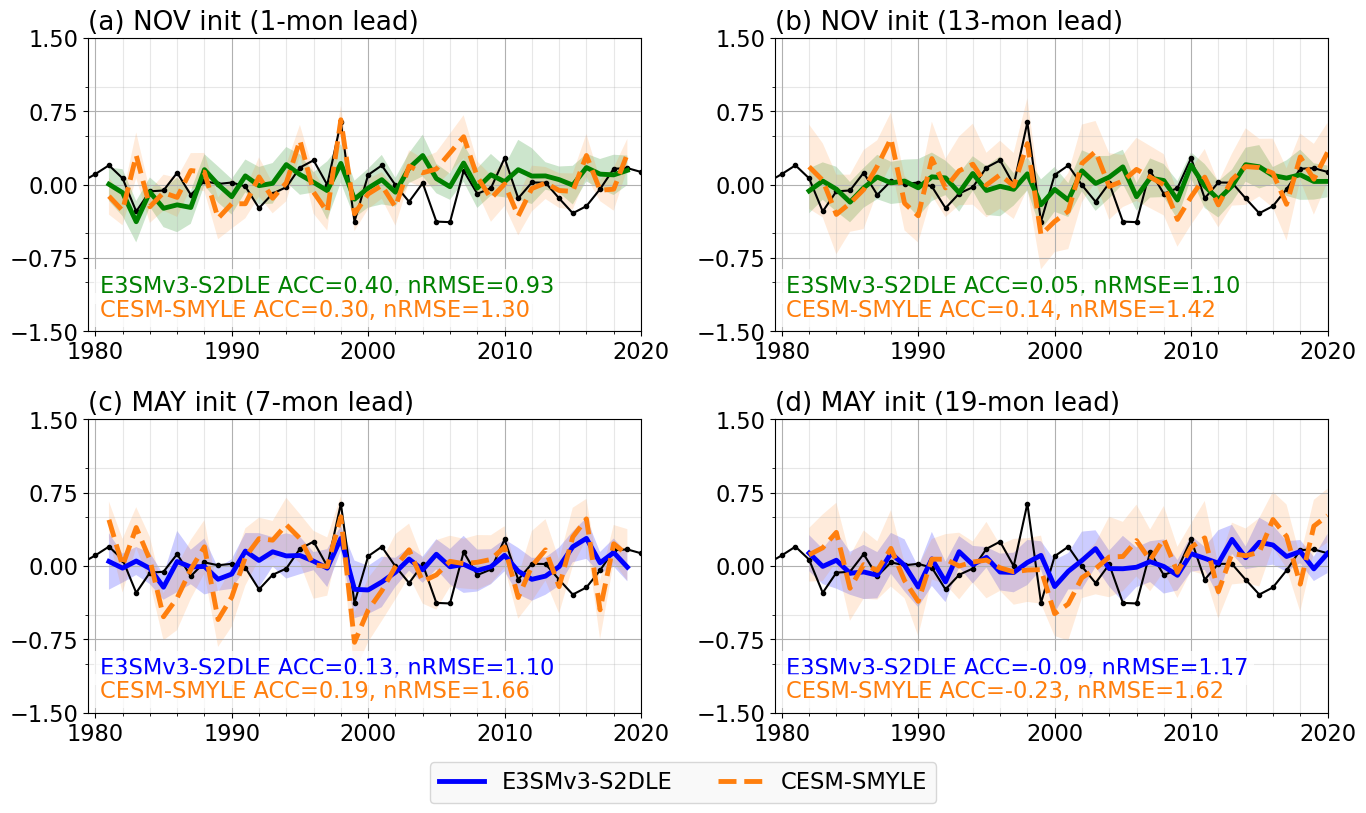

In [170]:
# -----------------------------
# Plot DJF Niño3.4 time series
# -----------------------------
# -----------------------------
# Plot setup: change values here to tune the figure
# -----------------------------
startmonths_requested = [11, 5]
djf_leads = {
    11: [3, 15],   # NOV init
    5: [9, 21],    # MAY init
}
startmonths_plot = [m for m in startmonths_requested if m in e3smle_seas.startmonth.values]
nrow = len(startmonths_plot)
ncol = 2

fontz = 18
title_fontz = fontz * 1.05
tick_fontz = fontz * 0.9
legend_fontz = fontz * 0.9
annotation_fontz = fontz * 0.9

fig_width = 14
row_height = fig_width * 0.6 / ncol
line_width = 3.5
obs_marker_size = 6
e3sm_spread_alpha = 0.2
smyle_spread_alpha = 0.15
grid_minor_alpha = 0.3
annotation_box = dict(facecolor="white", alpha=0.75, edgecolor="none")
e3sm_annotation_xy = (0.02, 0.13)
smyle_annotation_xy = (0.02, 0.05)

plot_ylim = plot_settings["ts_lim"]
major_yticks = plot_settings["ts_yticks"]
minor_yticks = np.arange(plot_ylim[0] + 0.5, plot_ylim[1], 0.5)
plot_xmin = 1979.5
plot_xmax = 2020.0
major_years = [1980, 1990, 2000, 2010, 2020]
minor_years = np.arange(1980, 2021, 2)

hindcast_label = {11: "NOV", 5: "MAY"}
hindcast_color = {11: "g", 5: "b"}
e3sm_label = "E3SMv3-S2DLE"
smyle_color = "tab:orange"
obs_color = "k"
figlabs = [["(a)", "(c)"], ["(b)", "(d)"]]
field = cfg.region_name
figfmt = "png"
period = f"{years}-{yeare}"
figname = figure_filename(field, f"{cfg.region_name.lower()}_time_series", ext=figfmt)
dpi = 300

plt.rcParams.update({
    "font.size": fontz,
    "axes.titlesize": title_fontz,
    "xtick.labelsize": tick_fontz,
    "ytick.labelsize": tick_fontz,
    "legend.fontsize": legend_fontz,
})
fig = plt.figure(figsize=(fig_width, row_height * nrow))

def _time_part_values(time_da, part, drop_missing=False):
    values = np.asarray(time_da.values).ravel()
    out = []

    for t in values:
        value = np.nan
        try:
            if t is not None:
                if hasattr(t, part):
                    value = getattr(t, part)
                else:
                    ts = pd.Timestamp(t)
                    if not pd.isna(ts):
                        value = getattr(ts, part)
        except (TypeError, ValueError, OverflowError):
            value = np.nan

        out.append(value)

    arr = np.asarray(out, dtype=float)
    if drop_missing:
        arr = arr[np.isfinite(arr)]
    return arr

def _year_values(time_da):
    return _time_part_values(time_da, "year")

if "M" in e3smle_seas.dims:
    member_dim = "M"
elif "member" in e3smle_seas.dims:
    member_dim = "member"
else:
    member_dim = None


for i, sm in enumerate(startmonths_plot):
    ax = fig.add_subplot(nrow, ncol, i * 2 + 1)
    ax2 = fig.add_subplot(nrow, ncol, i * 2 + 2)

    for a in [ax, ax2]:
        a.set_ylim(plot_ylim)
        a.set_yticks(major_yticks)
        a.set_yticks(minor_yticks, minor=True)

        # x-axis like the reference figure
        a.set_xlim([plot_xmin, plot_xmax])
        a.set_xticks(major_years)
        a.set_xticks(minor_years, minor=True)
        a.tick_params(axis="both", labelsize=tick_fontz)

        a.plot(
            obs_djf.time.dt.year,
            obs_djf,
            color=obs_color,
            marker=".",
            markersize=obs_marker_size
        )

        a.grid(True, which="major")
        a.grid(True, which="minor", alpha=grid_minor_alpha)

    for col_idx, (ax_panel, target_L) in enumerate(zip([ax, ax2], djf_leads[sm])):

        available_L = e3smle_seas.sel(startmonth=sm).L.values
        if target_L not in available_L:
            ax_panel.set_title(f"L={target_L} not available", loc="left", fontsize=title_fontz)
            continue

        data = e3smle_seas.sel(startmonth=sm, L=target_L)
        tmp_time = e3smle_seas_time.sel(startmonth=sm, L=target_L)
        skill_row = e3smle_seas_skill_plot.sel(startmonth=sm, L=target_L)

        valid_months = _time_part_values(tmp_time, "month", drop_missing=True)
        if valid_months.size and not np.all(valid_months == 1):
            raise ValueError(
                f"Expected DJF center month January for startmonth={sm}, L={target_L}; "
                f"found months {np.unique(valid_months)}"
            )

        lead = int(target_L) - 2
        acc = float(skill_row.corr.values)
        nrmse = float(skill_row.rmse.values)

        datatime = _year_values(tmp_time)

        valid = np.isfinite(datatime)
        datatime_plot = datatime[valid]
        data_plot = data.isel(Y=valid)

        titl = f"{hindcast_label[sm]} init ({lead}-mon lead)"

        figlabel = figlabs[col_idx][i]
        ax_panel.set_title(figlabel + " " + titl, loc="left", fontsize=title_fontz)

        if member_dim is not None:
            datamean = data_plot.mean(member_dim)
            datastd = data_plot.std(member_dim)
        else:
            datamean = data_plot
            datastd = xr.zeros_like(data_plot)

        ax_panel.plot(
            datatime_plot,
            datamean,
            color=hindcast_color[sm],
            linewidth=line_width,
            label=e3sm_label,
        )

        ax_panel.fill_between(
            datatime_plot,
            (datamean - datastd).values,
            (datamean + datastd).values,
            fc=hindcast_color[sm],
            alpha=e3sm_spread_alpha,
        )

        ax_panel.text(
            *e3sm_annotation_xy,
            f"{e3sm_label} ACC={acc:3.2f}, nRMSE={nrmse:3.2f}",
            transform=ax_panel.transAxes,
            fontsize=annotation_fontz,
            color=hindcast_color[sm],
            bbox=annotation_box,
        )

        # Optional CESM-SMYLE overlay for the same initialization month and DJF lead.
        if (
            "smyle_seas" in globals()
            and "smyle_seas_time" in globals()
            and sm in smyle_seas.startmonth.values
            and target_L in smyle_seas.sel(startmonth=sm).L.values
        ):
            smyle_data = smyle_seas.sel(startmonth=sm, L=target_L)
            smyle_tmp_time = smyle_seas_time.sel(startmonth=sm, L=target_L)

            smyle_datatime = _year_values(smyle_tmp_time)
            smyle_valid = np.isfinite(smyle_datatime)

            smyle_datatime_plot = smyle_datatime[smyle_valid]
            smyle_data_plot = smyle_data.isel(Y=smyle_valid)

            if "M" in smyle_data_plot.dims:
                smyle_member_dim = "M"
            elif "member" in smyle_data_plot.dims:
                smyle_member_dim = "member"
            else:
                smyle_member_dim = None

            if smyle_member_dim is not None:
                smyle_mean = smyle_data_plot.mean(smyle_member_dim)
                smyle_std = smyle_data_plot.std(smyle_member_dim)
            else:
                smyle_mean = smyle_data_plot
                smyle_std = xr.zeros_like(smyle_data_plot)

            ax_panel.plot(
                smyle_datatime_plot,
                smyle_mean,
                color=smyle_color,
                linewidth=line_width,
                linestyle="--",
                label="CESM-SMYLE",
            )

            ax_panel.fill_between(
                smyle_datatime_plot,
                (smyle_mean - smyle_std).values,
                (smyle_mean + smyle_std).values,
                fc=smyle_color,
                alpha=smyle_spread_alpha,
            )

            if (
                "smyle_seas_skill_plot" in globals()
                and sm in smyle_seas_skill_plot.startmonth.values
                and target_L in smyle_seas_skill_plot.sel(startmonth=sm).L.values
            ):
                smyle_skill_row = smyle_seas_skill_plot.sel(startmonth=sm, L=target_L)
                smyle_acc = float(smyle_skill_row.corr.values)
                smyle_nrmse = float(smyle_skill_row.rmse.values)
                ax_panel.text(
                    *smyle_annotation_xy,
                    f"CESM-SMYLE ACC={smyle_acc:3.2f}, nRMSE={smyle_nrmse:3.2f}",
                    transform=ax_panel.transAxes,
                    fontsize=annotation_fontz,
                    color=smyle_color,
                    bbox=annotation_box,
                )

        # if i == 0 and col_idx == 0:
        #     ax_panel.legend(loc="upper right", fontsize=legend_fontz)

# Collect handles and labels for a single 1-line legend at the bottom
handles, labels = ax_panel.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, 0.01),
    frameon=True,
    facecolor="#f9f9f9",
    edgecolor="lightgray",
    framealpha=0.9
)

fig.tight_layout(rect=[0, 0.06, 1, 1])
figpath = FIGURE_OUTDIR / figname
mov.save_figure(
    fig, figpath,
    mode="",
    metric=f"{cfg.region_name.lower()}_sst_skill",
    title=f"{cfg.region_name} SST Skill: {field}",
    caption=f"Verification period: {period}",
    dpi=dpi,
)
print("Saved figure:", figpath)
plt.show()

In [171]:
# -----------------------------
# Clean up Dask resources
# -----------------------------
close_cluster(cluster, client)